# Election-Volatility — does the vote really shake the market? 🗳️
### The 'sell vol into the election and collect the crush' trade, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![An_election_premium%3F: Misattributed](https://img.shields.io/badge/An_election_premium%3F-Misattributed-8b949e?style=flat-square)

Every four years the same story makes the rounds: US elections inject huge *uncertainty*, volatility spikes into the vote, and the option market pays a fat premium for it — so the clever move is to **sell volatility into the election and collect the 'vol crush'** when the result lands. This notebook asks the only questions that matter in plain English: *does volatility actually spike, does the option market over-charge for it, and is selling vol into elections any better than selling vol on any random Tuesday?*

> 📓 **This is the plain-language layer.** Want the t-stats, the placebo distribution and the excess-vs-baseline race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from election_volatility import data, strategy as st

def load_real_or_none():
    """Return (gspc, vix) from the shared cache, or (None, None) offline."""
    try:
        return data.load_real("^GSPC"), data.load_vix()
    except Exception as exc:
        print("real tapes unavailable (offline) -> synthetic tape:", exc)
        return None, None

GSPC, VIX = load_real_or_none()
HAVE_REAL = GSPC is not None
print("real cached tapes present:", HAVE_REAL)

# The offline synthetic control tape (always available) — a planted spike + excess VRP.
SB, SV, SEL, STRUTH = data.synthetic_daily(vol_bump=0.8, vrp=8.0, seed=318)


real cached tapes present: True


## The answer first 🎯

| Question | Plain answer |
|---|---|
| Does *realized* vol spike into election day? | **Barely.** ~+5% on average across 25 elections — indistinguishable from a random week. |
| Does *implied* vol (VIX) over-price it? | **A little, usually** — but one bad election (2008) wipes out the average, so we can't be sure. |
| Is selling vol *into elections* a real edge? | **No.** The money is the everyday 'sell vol, get paid' premium — elections add almost nothing, and you eat the rare disaster. |

> **In one line:** the eye-catching version of this trade wins ~89% of the time with a great-looking t-stat — but that's the *ordinary* variance-risk premium you'd earn any time, not an election edge, and it's paid for with a single **-23 vol-point** loss in 2008.

## 1 · The claim

Stated at full strength (and it has real academic backing — [Kelly, Pástor & Veronesi 2016](https://doi.org/10.1111/jofi.12406)): political events resolve uncertainty, so the option market charges a **variance-risk premium** for the dates that span them. Around a US presidential election you should therefore see (a) volatility rising into the vote, (b) implied vol (VIX) priced *above* the volatility that actually shows up, and (c) a profitable trade in **selling that implied vol** and buying it back cheaper after the result.

## 2 · So what?

If true, it's a calendar you can mark years in advance — election dates are fixed by law, no forecasting needed. A reliable 'sell vol into November every fourth year' overlay would be a rare thing: a *scheduled* risk premium. The catch every options trader knows: selling volatility is **picking up pennies in front of a steamroller** — it wins most of the time and then, occasionally, hands back years of pennies at once. So the real question isn't 'does it usually win' (it does); it's *'does the election add anything over selling vol all the time, after the steamroller?'*

## 3 · How would we even know?

Three honest tests, announced before we run them:

1. **Realized-vol spike** — for each election, compare actual volatility in the run-up to a normal baseline. If elections are special, the ratio is clearly above 1; if it hovers around 1, the spike is a myth.
2. **The premium** — compare the VIX going into the vote to the volatility that *actually* shows up after. Implied-minus-realized is what a vol seller pockets.
3. **The fair race** — run the *same* short-vol trade on hundreds of random non-election dates. If the election trade isn't clearly better than that baseline, what looks like an 'election premium' is just the everyday premium.

**What would make us say 'mirage':** a vol ratio near 1, a premium whose error bars cross zero, and an election trade that lands in the *middle* of the random-date pile.

## 4 · The teardown — let's actually look

First, the realized-vol spike. Does volatility actually climb into the vote? We draw it on whichever tape is available — the real S&P 500 if cached, otherwise the offline synthetic tape (clearly bannered).

mean ratio = 1.05   (1.0 = no spike)
on the real tape: t vs 1.0 = +0.54 -> basically no spike


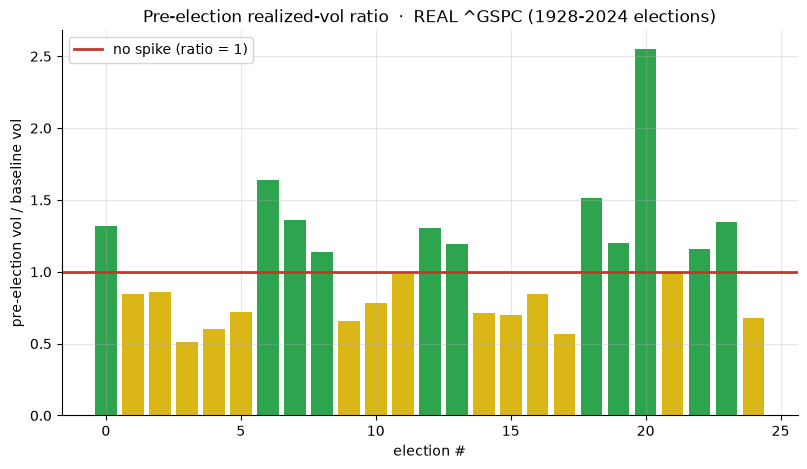

In [2]:
fig, ax = plt.subplots()
if HAVE_REAL:
    el = data.election_table()
    ratios = st.vol_ratio_around(GSPC, el['election_date'])
    tape = 'REAL ^GSPC (1928-2024 elections)'
else:
    ratios = st.vol_ratio_around(SB, SEL['election_date'])
    tape = 'SYNTHETIC control tape (planted spike)'
ax.bar(range(len(ratios)), ratios, color=[GREEN if r>1 else AMBER for r in ratios])
ax.axhline(1.0, color=RED, lw=2, label='no spike (ratio = 1)')
ax.set_title(f'Pre-election realized-vol ratio  ·  {tape}')
ax.set_xlabel('election #'); ax.set_ylabel('pre-election vol / baseline vol')
ax.legend()
print(f'mean ratio = {ratios.mean():.2f}   (1.0 = no spike)')
if HAVE_REAL:
    print(f'on the real tape: t vs 1.0 = {st.tstat(ratios,1.0):+.2f} -> '
          f'{"a real spike" if abs(st.tstat(ratios,1.0))>2 else "basically no spike"}')


On the **real** S&P 500 the average pre-election vol ratio is **1.05** (t vs 1.0 = **+0.54**) — only 44% of elections show *any* elevation, and the whole thing sits at the 66th percentile of random weeks. The 'markets convulse into election day' image is, on realized volatility, **not there.**

Now the premium and the trade. Does the VIX over-price the vol that follows — and is the election trade better than the same trade on random dates?

election carry mean = 6.15 vol pts ; always-on baseline = 3.77
election EXCESS over always-on = +2.38 vol pts


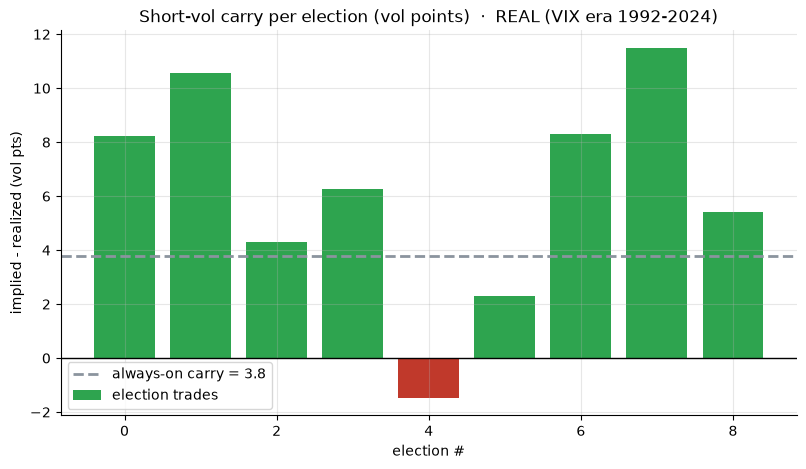

In [3]:
if HAVE_REAL:
    elv = data.election_table(min_year=1992)
    led = st.short_vol_carry(GSPC, VIX, elv['election_date'])
    rd = st.random_carry_dates(GSPC.loc['1992':], 6000, seed=99)
    base = st.short_vol_carry(GSPC, VIX, rd)['pnl_gross'].mean()
    tape = 'REAL (VIX era 1992-2024)'
else:
    led = st.short_vol_carry(SB, SV, SEL['election_date'])
    rd = st.random_carry_dates(SB, 6000, seed=99)
    base = st.short_vol_carry(SB, SV, rd)['pnl_gross'].mean()
    tape = 'SYNTHETIC control tape'
elec = led['pnl_gross'].to_numpy()
fig, ax = plt.subplots()
ax.bar(range(len(elec)), elec, color=[GREEN if x>0 else RED for x in elec], label='election trades')
ax.axhline(base, color=GREY, lw=2, ls='--', label=f'always-on carry = {base:.1f}')
ax.axhline(0, color='k', lw=1)
ax.set_title(f'Short-vol carry per election (vol points)  ·  {tape}')
ax.set_xlabel('election #'); ax.set_ylabel('implied - realized (vol pts)'); ax.legend()
print(f'election carry mean = {elec.mean():.2f} vol pts ; always-on baseline = {base:.2f}')
print(f'election EXCESS over always-on = {elec.mean()-base:+.2f} vol pts')


There's the trap, in one chart. The election trade earns **+6.2 vol points** on average and wins 89% of the time — *but the grey dashed line is the same trade on random dates, and it already earns **+3.8**.* The election **excess** over that baseline is only **+2.4 vol points**, and notice the one deep-red bar: **2008**, election week inside the financial crisis, where realized vol (77) blew past the 54 implied for a **-23** disaster. That single bar is the steamroller.

## 5 · The verdict

- **Signal — Weak.** Realized vol doesn't spike (ratio 1.05). Implied vol over-prices it *most* of the time (premium positive 78% of elections, averaging +5.2 vol points) — but the average is dragged to a t of just +1.28 by 2008, below the bar we need to call it real.
- **Tradability — Mirage.** The pretty win-rate and t-stat are the *everyday* variance-risk premium, not an election edge. Strip out the always-on carry and the election adds an insignificant +2.4 vol points — while you carry the full 2008-style tail.
- **An election premium? — Misattributed.** What looks like 'election risk' is mostly the premium you'd collect selling vol any time.

## 6 · Could you actually trade it?

Sure — and most months you'd be happy: short vol, collect the crush, ~89% winners. But you'd collect almost exactly what a 'short vol all the time' fund collects, you'd have your capital tied up only every fourth November (a *calendar*-capacity problem), and you'd be on the hook for the 2008-shaped loss with no extra premium to compensate for choosing the election as your moment. The desk's rule decides it: race a part-time carry against the always-on carry on **excess**, and the excess here can't be told from zero. There's no free election lunch — only the usual vol-selling lunch, eaten less often.

## 7 · Going further 🚪

Threads worth a fork: (a) **politically-sensitive sectors** (Boutchkova et al. 2012) may carry a real election vol premium even when the index doesn't; (b) **the VIX term structure** — does the election 'kink' in the futures curve pay better than the spot trade; (c) **non-US elections** (UK, France, EM) where the sample is bigger and the surprises larger; (d) **referendums and contested results** (Brexit, 2000) as a separate, higher-variance event class. The synthetic tape here lets you plant any of these and check the harness can find them before you trust it on the real thing.